# Versuchsbeschreibung und Versuchsdurchführung

Das versuchstechnische Praktikum "Hochauftriebssystem am Tragflügelprofil" fand am 4. Mai von 10 bis 12 Uhr an der Hochschule München statt. Ziel des Praktikums war es, die Druckverteilung sowie die Entwicklung der Grenzschicht am Flügelprofil zu untersuchen. 
Zu Beginn der Veranstaltung gab es eine theoretische Einführung in das Thema. Dabei wurden die Themengebiete Einfluss des Druckgradienten auf das Grenzschichtverhalten, Maßnahmen zur Änderung des Geschwindigkeitsprofils und die Aufteilung der Kräfte am Tragflügel behandelt.

Der Versuch wurde an einem Modell des Tragflügelprofils mit einem festen Koordinatensystem durchgeführt. Die Druckmessung erfolgte über 60 Bohrungen, die auf der Flügeloberseite FO, der Flügelunterseite FU, der Klappenoberseite KO sowie der Klappenunterseite KU platziert sind. Während des Versuchs waren allerdings einige Bohrungen entweder nicht belegt oder konnten keine Druckwerte messen, sodass an diesen Stellen keine Daten erfasst wurden. Die Datenerfassung erfolgte durch die Drucksensoren. Für die Messung von $p_i - p_\infty$ wurden zwei Schläuche genutzt: auf der einen Seite wurde der Schlauch auf dem Modell angeschlossen, auf der anderen Seite wurde der Referenzdruck gemessen. Da der Versuch im Windkanal mit offener Messstrecke durchgeführt wurde, gilt, dass der Referenzdruck gleich dem Druck im Raum entspricht. Das Modell des Profils ist unter anderem mit zwei Endscheiben ausgestattet, um die Randwirbelbildung zu vermeiden. Mithilfe eines kinematischen Hebels kann die Klappe des Modells gesteuert werden, sodass auch während des Versuchs der Klappenwinkel geändert werden kann. Die Änderung des Anstellwinkels soll manuell und bei ausgeschaltetem Windkanal erfolgen. 

Der dynamische Druck während des Versuchs wurde mithilfe eines Prandtl-Rohrs gemessen. Dadurch kann in den folgenden Berechnungen die Anströmgeschwindigkeit ermittelt werden. Der Versuch startete bei einem Klappenwinkel von $\eta=-2^\circ$ und einem Anstellwinkel von $\alpha=0^\circ$, wobei bei jeder nächsten Messung diese Winkel geändert wurden. Zu beachten ist, dass bei der Erhöhung des Anstellwinkels auch die Drehzahl der Gebläse ebenfalls erhöht werden musste, um den Profilwiderstand auszugleichen.

# Tagesaktuelle Werte 

Für eine korrekte Interpretation der errechneten und gemessenen Messergebnisse ist es erforderlich die tagesaktuellen Werte, die bei der Versuchsdurchführung eine Rolle spielen, wie relative Luftfeuchte, Temperatur und Druck, zu bestimmen. Die daraus berechneten Dichte und kinematische Viskosität werden in der Auswertung für die Berechnung der Strömungsgeschwindigkeit und der Reynoldszahl verwendet. Die Rechnung ist im Folgenden dargestellt. 

### Berechnung der spezifischen Gaskonstante $R_s$
Da die am 04. Mai gemessene relative Luftfeuchte den Wert $\phi_L$ = 55 % erreicht und somit $\phi_L$ > 50 % ist, muss die Gaskonstante korrigiert werden:\
$$R_\phi = \frac{R_{\phi=0}}{1-\frac{0,377 \cdot \phi \cdot p_D (t)}{p_\infty}}$$

Der Sättigungsdampfdruck kann für eine Lufttemperatur $t_0$ = 20 °C über die Sättigungsdampftafel und Interpolation abgeschätzt werden.\
$$p_D(t_0) = p_{D(t1)} + \frac{t_0 - t_1}{t_2 - t_1} \cdot (p_{D(t2)} - p_{D(t1)})$$

Die Sättigungstafel wurde aus den Unterlagen der Vorlesung "Thermodynamik und Wärmeübertragung 1" entnommen.

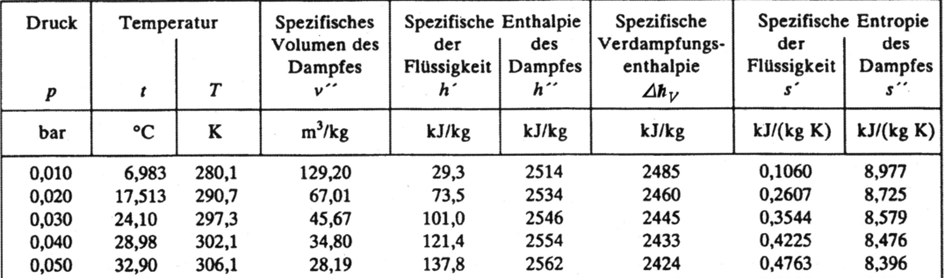

Die gemessene Lufttemperatur beträgt 293,15 K. Deshalb werden für die Interpolation die Werte $t_1$ = 290,7 K und $t_2$ = 297,3 K betrachtet.

$$p_D(t_0) = 0{,}020\,\text{bar} + \frac{293,15 - 290,7}{297,3 - 290,7} \cdot (0{,}030\,\text{bar} - 0{,}020\,\text{bar})$$

In [1]:
t0 = 293.15
t1 = 290.7
t2 = 297.3

p1 = 0.020
p2 = 0.030

p_D_bar = p1 + (t0 - t1) / (t2 - t1) * (p2 - p1)
p_D = p_D_bar * 10**5

print(f"Interpolierter Sättigungsdampfdruck p_D(t0) = {p_D:.2f} Pa")

Interpolierter Sättigungsdampfdruck p_D(t0) = 2371.21 Pa


Somit lässt sich die korrigierte Gaskonstante $R_\phi$ ermitteln

$$R_\phi = \frac{287,05}{1-\frac{0,377 \cdot 0,55 \cdot 2.371,21}{93.762,29}}$$

In [2]:
R_phi = 287.05 / (1 - (0.377 * 0.55 * 2371.21) / 93762.29)
print(f"R_phi = {R_phi:.2f} J/(kg·K)")

R_phi = 288.56 J/(kg·K)


Die aktuelle Luftdichte $\rho$ wird mit der umgeformten idealen Gasgleichung berechnet:
$$\rho = \frac {p_{umgebung}}{R_{S} \cdot t_0}$$

$$\rho = \frac{93.762{,}29\,\text{Pa}}{288{,}56\,\frac{J}{kg\,K} \cdot 293{,}15\,\text{K}}$$

In [3]:
rho = 93762.29 / (288.56 * 293.15)
print(f"rho = {rho:.3f} kg/m³")

rho = 1.108 kg/m³


Die Dynamische Viskosität $\eta$ wird durch die Sutherlandformel allgemein beschrieben:
$$\eta=\eta_0 \cdot \frac{T_0 + C}{T + C} \cdot \left(\frac{T}{T_0}\right)^{\frac{3}{2}}$$


Hierzu werden luftspezifische Konstanten und Referenztemperaturen benötigt:\
Sutherlandskonstante $C$ = 120 K\
Referenztemperatur $T_0$ = 291,15 K\
Referenzviskosität $\eta_0 = 18{,}27 \cdot 10^{-6}\,\text{Pa}\cdot\text{s}$

$$\eta = 18{,}27 \cdot 10^{-6}\,\text{Pa}\cdot\text{s}
\cdot \frac{291{,}15\,\text{K} + 120\,\text{K}}{293{,}15\,\text{K} + 120\,\text{K}}
\cdot \left(\frac{293{,}15\,\text{K}}{291{,}15\,\text{K}}\right)^{\frac{3}{2}}$$

In [4]:
eta = 18.27e-6 * (
    (291.15 + 120) / (293.15 + 120)
) * (
    (293.15 / 291.15) ** (3/2)
)

print(f"eta = {eta:.4e} Pa·s")

eta = 1.8369e-05 Pa·s


Alle Versuche werden bei einem konstanten Staudruck von $q_\infty =  400\,\text{Pa}$ gefahren.


$$q_\infty = \frac{\rho}{2}u_\infty^2$$

Somit kann die Anströmgeschwindigkeit $u_\infty$ bestimmt werden:
$$u_\infty = \sqrt{\frac{2 \cdot q_\infty}{\rho}}$$

$$u_\infty = \sqrt{\frac{2 \cdot 400\,\text{Pa}}{1{,}108\,\frac{kg}{m^3}}}$$

In [5]:
import math

u_inf = math.sqrt((2 * 400) / (1.108))

print(f"u_inf = {u_inf:.2f} m/s")

u_inf = 26.87 m/s


Die Reynoldszahl kann in diesem Versuch mithilfe der Flügeltiefe $c$ = 0,35 m bestimmt werden.
$$Re_c = \frac{\rho \cdot u_\infty \cdot c}{\eta}$$
$$Re_c = \frac{1{,}108\,\frac{kg}{m^3} \cdot 26{,}87\,\frac{m}{s} \cdot 0{,}35\,\text{m}}{1{,}8369 \cdot 10^{-5}\,\text{Pa}\cdot\text{s}}$$


In [6]:
Re_c = (1.108 * 26.87 * 0.35) / (1.8369e-5)
print(f"Re_c = {Re_c:.2e}")

Re_c = 5.67e+05


| Parameter | Wert |
|---|---|
| Ort | Hochschule München |
| Datum | 04.05.2026 |
| Uhrzeit | 10:00 bis 12:00 Uhr |
| Umgebungstemperatur | $t_0 = 20^\circ\text{C} \; (293{,}15\,\text{K})$ |
| Luftdruck | $p_\infty = 93\,762{,}29\,\text{Pa}$ |
| Relative Luftfeuchte | $\phi_L = 55\%$ |
| Luftdichte | $\rho = 1{,}108\,\mathrm{kg\,m^{-3}}$ |
| Dynamische Viskosität | $\eta = 1{,}8369 \cdot 10^{-5}\,\mathrm{Pa\,s}$ |
| Reynoldszahl | $Re_c = 5{,}67 \cdot 10^5$ |

# $c_p$-Verteilung für Anstell- und Klappenwinkel-Variationen

Die Auswertung des versuchtechnischen Praktikums "Hochauftriebssystem am Tragflügelprofil" erfolgt mithilfe eines Jupyter- Notebooks. Für die Ausführung des Codes werden dabei die folgenden Bibliotheken genutzt:

In [7]:
import math
import os 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import interpolate
from scipy.integrate import trapezoid

Um den Verlauf des Druckbeiwerts $c_p$ zu verfolgen, wurden insgesamt über 67 Druckbohrungen auf dem Modell platziert. Alle diese Bohrungen sind über Schläuche mit einem Mehrkanalsystem verbunden, sodass die die Druckwerte der verschiedenen Messstellen zum Drucksensor geleitet werden. Die resultierenden Messungen werden über ein LabVIEW-System übertragen und als Excel-Datei gespeichert. 

## $c_p$-Verteilung für Anstellwinkel-Variation

Im Rahmen dieses Versuchs soll der $c_p$-Verlauf für unterschiedliche Anstellwinkelkonfigurationen ermittelt werden. Dabei wurden die Druckwerte bei Anstellwinkeln von $-5^\circ$ bis zur $25^\circ$ mit einer Differenz von 5 Grad gemessen $(\alpha=-5^\circ, 0^\circ, 5^\circ, 10^\circ, 15^\circ, 20^\circ, 25^\circ)$.
Die resultierenden Ergebnisse wurden in Excel-Dateien erfasst und können für die weitere Verarbeitung genutzt werden.

Der folgende Code besteht aus zwei Teilen. Der erste Teil wurde zum Einlesen der Excel-Daten genutzt. Mithilfe dieses Codes sollen die gemessenen Druckwerte für die jeweilige Anstellwinkel-Konfiguration an das Jupyter-Notebook übergeben werden. 
Im zweiten Teil des Codes wurde der $c_p$-Wert an jeweilige Bohrungsposition mithilfe der folgenden Formel bestimmt:
$$c_p(i) = \frac{p_i - p_\infty}{p_{\infty,\mathrm{dyn}}}$$
Die Drucksensoren erfassen die Differenz von statischem Druck $p_i$ an der Druckbohrung und statischem Druck in der Strömung $p_\infty$. Deshalb können diese Daten direkt aus den Excel-Dateien entnommen werden. Darüber hinaus werden alle Versuche bei einem konstanten Staudruck von 400 Pa gefahren. Es gilt $p_{\infty,\mathrm{dyn}} = 400\,\mathrm{Pa}$.

Nach der Ausführung dieses Codes wird eine Python-Liste erzeugt. In ersten Spalte der Liste ist die Koordinate der jeweiligen Bohrung als Verhältnis zwischen dem Abstand von der Nase $x$ und der Flügeltiefe $c$ ($\frac{x}{c}$) angegeben. In den nächsten Spalten sind die ermittelten $c_p$-Werte für unterschiedliche Anstellwinkel-Konfigurationen sichtbar. 

Es ist zu beachten, dass die Messpositionen FO10a, FO24, FO25, FU7a, FU13a, FU23, KO30 und KU31 nicht belegt sind, sodass an diesen Stellen keine Messdaten erfasst wurden. Darüber hinaus wurde nach Analyse der Druckwerte festgestellt, dass es auf der Position FO15 zu einer unerwarteten Änderung der Druckwerte kommt. So wurden beispielsweise auf den Positionen FO14 und FO16 die Drücke von -152,44 Pa bzw. -165,13 Pa gemessen, während der Druckwert auf der Position FO15 lediglich -2,30 Pa beträgt. Diese Abweichung kann durch Bohrungsverstopfung oder undichte Schlauchanschlüsse verursacht werden. 
Die Bestimmung des $c_p$-Wertes an den fehlenden sowie defekten Stellen erfolgt mithilfe der Methode der linearen Interpolation unter der Verwendung der Funktion $interpolate$.

Aufgrund der begrenzten Platzverhältnisse an der Kante des Flügelprofils war keine Bohrung möglich. Aus diesem Grund sollen die Daten ab KO30 extrapoliert werden.

In [8]:
import numpy as np
import pandas as pd

def lese_druckdaten(filepath):
    """
    Liest Druckdaten aus einer Oberseite- oder Unterseite-xlsx-Datei.
    Gibt dict zurück mit Einträgen für FO, FU, KO, KU (je nach Datei).
    NaN-Werte (defekte Kanäle) werden linear interpoliert.
    """
    df = pd.read_excel(filepath)
    df.columns = df.columns.str.replace("\n", " ").str.strip()

    bohrung_col = [c for c in df.columns if 'Bohrung' in c or 'Nummer' in c][0]
    druck_col   = [c for c in df.columns if 'Druck in Pa' in c][0]
    xc_col      = [c for c in df.columns if 'x/c' in c][0]

    df[bohrung_col] = df[bohrung_col].astype(str).str.strip()

    result = {}
    for typ in ['FO', 'FU', 'KO', 'KU']:
        mask = df[bohrung_col].str.startswith(typ)
        if mask.any():
            xc    = df.loc[mask, xc_col].values.astype(float)
            druck = df.loc[mask, druck_col].values.astype(float)

            # NaN-Werte (defekte Kanäle) linear interpolieren
            nan_mask = np.isnan(druck)
            if nan_mask.any():
                druck[nan_mask] = np.interp(
                    xc[nan_mask], xc[~nan_mask], druck[~nan_mask]
                )

            result[typ] = {'xc': xc, 'druck': druck}
    return result

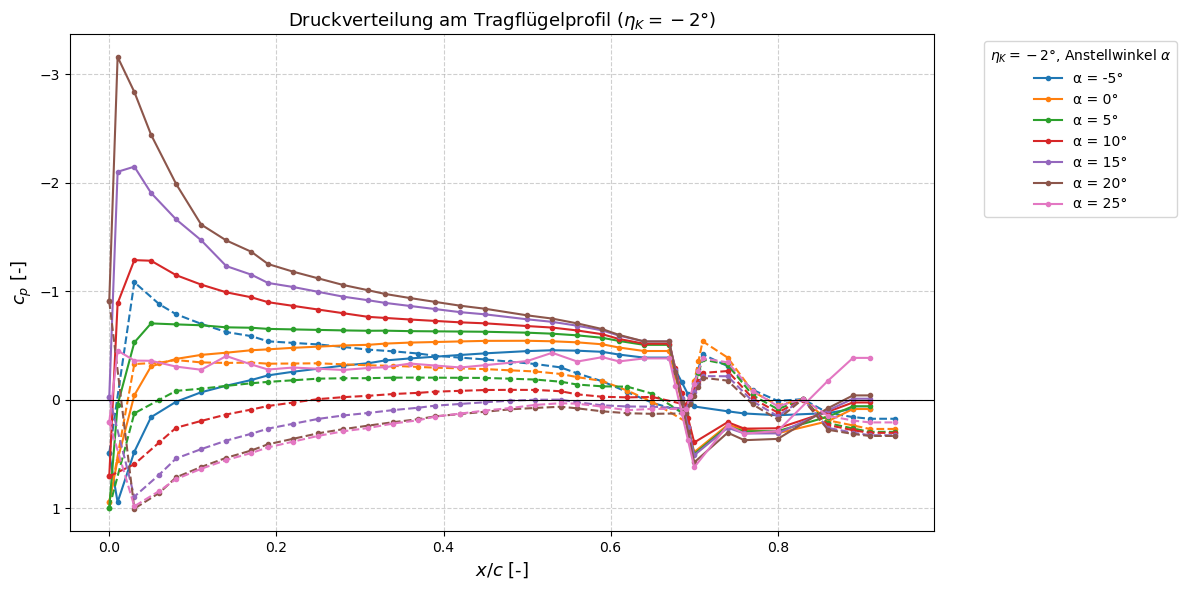

In [9]:
p_dyn_ref = 400  # Pa
c_profil  = 0.35 # m

import matplotlib.pyplot as plt
import numpy as np

def verbinde_mit_spalt(x_haupt, cp_haupt, x_klappe, cp_klappe, n_punkte=3):
    """
    Verbindet Flügel- und Klappenkurve mit Spalt-Interpolation.
    Trimmt automatisch Flügelpunkte die nach dem Klappenstart liegen.
    """
    # Nur Flügelpunkte VOR dem ersten Klappenpunkt behalten
    mask = x_haupt < x_klappe[0]
    x_trim  = x_haupt[mask]
    cp_trim = cp_haupt[mask]

    if len(x_trim) == 0:
        return x_klappe, cp_klappe

    # Lineare Interpolation im Spalt
    x_gap  = np.linspace(x_trim[-1], x_klappe[0], n_punkte + 2)[1:-1]
    cp_gap = np.interp(x_gap,
                       [x_trim[-1], x_klappe[0]],
                       [cp_trim[-1], cp_klappe[0]])

    return (np.concatenate([x_trim,  x_gap,  x_klappe]),
            np.concatenate([cp_trim, cp_gap, cp_klappe]))

fig, ax = plt.subplots(figsize=(12, 6))
color_cycle = plt.cm.tab10.colors

alpha_var = [-5, 0, 5, 10, 15, 20, 25]
dateien_alpha = [
    ['2024-05-06_11-48_alpha-5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha-5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha0_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha0_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha10_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha10_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha15_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha15_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha20_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha20_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha25_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha25_eta-2_Messdaten_Unterseite.xlsx'],
]

for i, alpha in enumerate(alpha_var):      # bzw. eta in enumerate(eta_var)
    color = color_cycle[i % len(color_cycle)]
    d_ober  = lese_druckdaten(dateien_alpha[i][0])
    d_unter = lese_druckdaten(dateien_alpha[i][1])

    # Oberseite (Saugseite) — gestrichelt
    x_FO  = d_ober['FO']['xc'];   cp_FO = d_ober['FO']['druck']  / p_dyn_ref
    x_KO  = d_unter['KO']['xc'];  cp_KO = d_unter['KO']['druck'] / p_dyn_ref
    x_o, cp_o = verbinde_mit_spalt(x_FO, cp_FO, x_KO, cp_KO)

    # Unterseite (Druckseite) — durchgezogen
    x_FU  = d_unter['FU']['xc'];  cp_FU = d_unter['FU']['druck'] / p_dyn_ref
    x_KU  = d_unter['KU']['xc'];  cp_KU = d_unter['KU']['druck'] / p_dyn_ref
    x_u, cp_u = verbinde_mit_spalt(x_FU, cp_FU, x_KU, cp_KU)

    # FU1 = FO1: Unterseite beginnt am Staupunkt (x/c=0, cp=FO1)
    x_u  = np.insert(x_u,  0, x_FO[0])
    cp_u = np.insert(cp_u, 0, cp_FO[0])

    ax.plot(x_o, cp_o, '-', color=color, marker='o', ms=3, label=f'α = {alpha}°')  # Saugseite gestrichelt
    ax.plot(x_u, cp_u, '--',  color=color, marker='o', ms=3)                          # Druckseite durchgezogen

ax.invert_yaxis()
ax.set_xlabel(r'$x/c$ [-]', fontsize=13)
ax.set_ylabel(r'$c_p$ [-]', fontsize=13)
ax.set_title(r'Druckverteilung am Tragflügelprofil ($\eta_K = -2°$)', fontsize=13)
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title=r'$\eta_K = -2°$, Anstellwinkel $\alpha$',
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Plot der $c_p$-Kurven für die Anstellwinkel-Variation

Nachdem der Wert $c_p$ für die jeweilige Messposition ermittelt wurde, kann die Verteilung des Druckbeiwerts für unterschiedliche Anstellkonfigurationen in einem Diagramm dargestellt werden.

### Analyse der Staupunktpositionen für die Anstellwinkelkonfiguration

Aus dem Diagrammverlauf ist es deutlich zu erkennen, dass sich die Staupunkte am vorderen Rand des Profils befinden. Bei einem Staupunkt wird die Luftströmung sich auf zwei Strömungen aufteilt. 

Der erste Staupunkt kann bei einem Anstellwinkel von $\alpha=5^\circ$ auf der Flügeloberseite an der Stelle FO1 beobachtet werden. Dieser Staupunkt befindet sich am nächsten zur Nasenspitze und kann dadurch erklärt werden, dass die Strömung aufgrund des relativ kleinen Anstellwinkels direkt an der Vorderkante des Profils eintrifft. Die weiteren Staupunkten entstehen bei den Anstellwinkeln von $\alpha=20^\circ$ und $\alpha=25^\circ$. Im Unterschied zum ersten Staupunkt wird der Druckbeiwert $c_p=0$ nicht an der Flügeloberseite, sondern an der Unterseite des Profils erreicht. Der Grund dafür ist, dass sich der Staupunkt mit zunehmendem Anstellwinkel zur Profilunterseite verschiebt. Dies entsteht infolge der asymmetrischen Umlenkung der Strömung um das Profil. Dadurch beschleunigt die Strömung auf der Oberseite stärker, während sich auf der Unterseite höhere Drücke ausbilden. 

### $c_p$-Verteilung für Klappenwinkel-Variation

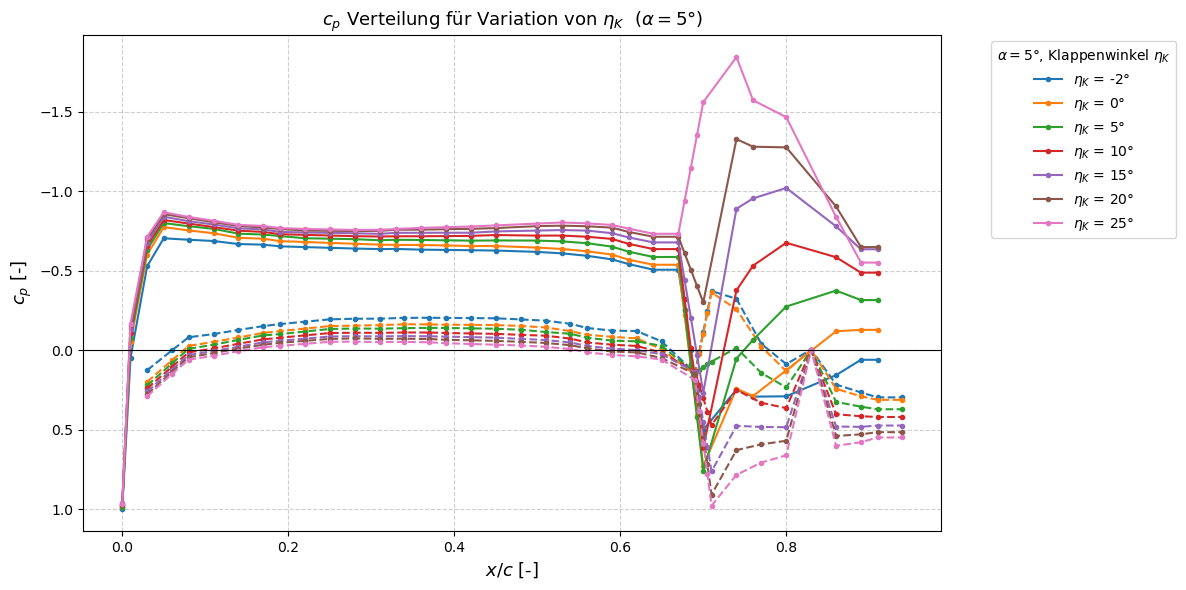

In [17]:
fig, ax = plt.subplots(figsize=(12, 6))
color_cycle = plt.cm.tab10.colors

eta_var = [-2, 0, 5, 10, 15, 20, 25]
dateien_eta = [
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta0_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta0_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta5_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta5_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta10_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta10_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta15_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta15_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta20_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta20_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta25_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta25_Messdaten_Unterseite.xlsx'],
]

for i, eta in enumerate(eta_var):
    color = color_cycle[i % len(color_cycle)]
    d_ober  = lese_druckdaten(dateien_eta[i][0])
    d_unter = lese_druckdaten(dateien_eta[i][1])

    # Oberseite: FO + KO (geometrisch obere Flächen) — durchgezogen
    x_FO  = d_ober['FO']['xc'];   cp_FO = d_ober['FO']['druck']  / p_dyn_ref
    x_KO  = d_unter['KO']['xc'];  cp_KO = d_unter['KO']['druck'] / p_dyn_ref
    x_o, cp_o = verbinde_mit_spalt(x_FO, cp_FO, x_KO, cp_KO)

    # Unterseite: FU + KU (geometrisch untere Flächen) — gestrichelt
    x_FU  = d_unter['FU']['xc'];  cp_FU = d_unter['FU']['druck'] / p_dyn_ref
    x_KU  = d_unter['KU']['xc'];  cp_KU = d_unter['KU']['druck'] / p_dyn_ref
    x_u, cp_u = verbinde_mit_spalt(x_FU, cp_FU, x_KU, cp_KU)

    ax.plot(x_o, cp_o, '-',  color=color, marker='o', ms=3, 
        label=f'$\\eta_K$ = {eta}°')   # eta statt alpha!
    ax.plot(x_u, cp_u, '--', color=color, marker='o', ms=3)

ax.invert_yaxis()
ax.set_xlabel(r'$x/c$ [-]', fontsize=13)
ax.set_ylabel(r'$c_p$ [-]', fontsize=13)
ax.set_title(r'$c_p$ Verteilung für Variation von $\eta_K$  ($\alpha = 5°$)', fontsize=13)
ax.axhline(0, color='black', linewidth=0.8)
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend(title=r'$\alpha = 5°$, Klappenwinkel $\eta_K$',
          bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

### Plot der $c_p$-Kurven für die Klappenwinkel-Variation

### Analyse der Staupunktpositionen für die Klappenwinkelkonfiguration

Nach Analyse des Diagramms für Klappenwinkelkonfiguration kann festgestellt werden, dass sich der Staupunkt auch hier am vorderen Rand des Profils bei $\eta=-2^\circ$, $\eta=5^\circ$, $\eta=20^\circ$ und $\eta=25^\circ$ befindet. Außerdem aufgrund des veränderten Anstellwinkels bei einem Klappenwinkel $\eta=25^\circ$ kann sich der Staupunkt leicht verschieben, würde aber in der Nähe des vorderen Randes bleiben. Aus dem Diagramm ist es auch zu bemerken, dass der Wert $c_p=1$ bei einem Klappenwinkel von $\eta=25^\circ$ auf einer Position von $x/c=0,73$ erreicht wurde. Allerdings ist es schwierig, die Genauigkeit dieser Aussage abzuschätzen, weil die Druckwerte für diese Position durch lineare Interpolation ermittelt wurden. 

## 3.2 Berechnung des Kraftbeiwerts $c_N$ und der Normalkraft $N'$

Der Kraftbeiwert $c_N$ beschreibt die dimensionslose Normalkraft auf das Profil und wird durch numerische Integration der $c_p$-Verteilung über die normierte Profiltiefe $x/c$ berechnet:

$$c_N = \int_0^1 \left( c_{p,\text{unten}} - c_{p,\text{oben}} \right) \, d\left(\frac{x}{c}\right)$$

Da die Drucksensoren bereits Differenzdrücke $p_i - p_\infty$ liefern, ergibt sich der Druckbeiwert direkt zu:

$$c_p(i) = \frac{\text{Messwert [Pa]}}{q_\infty}$$

Gemäß den Hinweisen der Versuchsbeschreibung werden folgende Ergänzungen vorgenommen:
1. Der erste Messpunkt der Unterseite (FU1) wird auf den Wert der Oberseite (FO1) gesetzt, da der Staupunkt zwischen beiden Seiten liegt.
2. Defekte Druckkanäle werden durch lineare Interpolation zwischen den benachbarten Messwerten ersetzt.
3. An der Hinterkante der Klappe wird $c_p = 0$ angenommen.

Die numerische Integration erfolgt mithilfe der Trapezregel. Die Normalkraft pro Tiefeneinheit $N'$ ergibt sich anschließend zu:

$$N' = c_N \cdot q_\infty \cdot c$$

mit der Profiltiefe $c = 0{,}35\,\text{m}$ und dem Staudruck $q_\infty = 400\,\text{Pa}$.

In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid
 
folder_path = r""   # leer = Notebook-Ordner
p_dyn_ref   = 400   # Pa
c_profil    = 0.35  # m (Versuchsbeschreibung Seite 13)

In [12]:
def lese_druckdaten(filepath):
    df = pd.read_excel(filepath)
    df.columns = df.columns.str.replace("\n", " ").str.strip()

    bohrung_col = [c for c in df.columns if 'Bohrung' in c or 'Nummer' in c][0]
    druck_col   = [c for c in df.columns if 'Druck in Pa' in c][0]
    xc_col      = [c for c in df.columns if 'x/c' in c][0]

    df[bohrung_col] = df[bohrung_col].astype(str).str.strip()

    result = {}
    for typ in ['FO', 'FU', 'KO', 'KU']:
        mask = df[bohrung_col].str.startswith(typ)
        if mask.any():
            xc    = df.loc[mask, xc_col].values.astype(float)
            druck = df.loc[mask, druck_col].values.astype(float)

            # NaN-Werte linear interpolieren (defekte Kanäle)
            nan_mask = np.isnan(druck)
            if nan_mask.any():
                druck[nan_mask] = np.interp(xc[nan_mask], xc[~nan_mask], druck[~nan_mask])

            result[typ] = {'xc': xc, 'druck': druck}
    return result
 
 
def berechne_cN(daten_ober, daten_unter, p_dyn):
    cp_FO = daten_ober['FO']['druck']  / p_dyn
    cp_KO = daten_unter['KO']['druck'] / p_dyn
    cp_FU = daten_unter['FU']['druck'] / p_dyn
    cp_KU = daten_unter['KU']['druck'] / p_dyn

    x_FO = daten_ober['FO']['xc']
    x_KO = daten_unter['KO']['xc']
    x_FU = daten_unter['FU']['xc']
    x_KU = daten_unter['KU']['xc']

    cp_FU[0] = cp_FO[0]

    # Oberseite: FO + KO
    x_o  = np.concatenate([x_FO, x_KO])
    cp_o = np.concatenate([cp_FO, cp_KO])
    idx  = np.argsort(x_o)
    x_o, cp_o = x_o[idx], cp_o[idx]

    # Unterseite: FU + KU
    x_u  = np.concatenate([x_FU, x_KU])
    cp_u = np.concatenate([cp_FU, cp_KU])
    idx  = np.argsort(x_u)
    x_u, cp_u = x_u[idx], cp_u[idx]

    x_end = max(x_o[-1], x_u[-1])
    if x_o[-1] < x_end:
        x_o  = np.append(x_o,  x_end); cp_o = np.append(cp_o, 0.0)
    if x_u[-1] < x_end:
        x_u  = np.append(x_u,  x_end); cp_u = np.append(cp_u, 0.0)

    cN = trapezoid(cp_u, x_u) - trapezoid(cp_o, x_o)
    return cN

In [13]:
alpha_var = [-5, 0, 5, 10, 15, 20, 25]
 
dateien_alpha = [
    ['2024-05-06_11-48_alpha-5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha-5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha0_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha0_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha10_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha10_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha15_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha15_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha20_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha20_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-52_alpha25_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-52_alpha25_eta-2_Messdaten_Unterseite.xlsx'],
]
 
cN_alpha     = []
N_prim_alpha = []
 
for i, alpha in enumerate(alpha_var):
    d_ober  = lese_druckdaten(os.path.join(folder_path, dateien_alpha[i][0]))
    d_unter = lese_druckdaten(os.path.join(folder_path, dateien_alpha[i][1]))
    cN      = berechne_cN(d_ober, d_unter, p_dyn_ref)
    N_prim  = cN * p_dyn_ref * c_profil
    cN_alpha.append(cN)
    N_prim_alpha.append(N_prim)
    print(f"alpha = {alpha:+3d}°  →  c_N = {cN:.4f},   N' = {N_prim:.2f} N/m")

alpha =  -5°  →  c_N = -0.1009,   N' = -14.12 N/m
alpha =  +0°  →  c_N = 0.1103,   N' = 15.45 N/m
alpha =  +5°  →  c_N = 0.3024,   N' = 42.34 N/m
alpha = +10°  →  c_N = 0.5496,   N' = 76.94 N/m
alpha = +15°  →  c_N = 0.7801,   N' = 109.21 N/m
alpha = +20°  →  c_N = 0.9421,   N' = 131.89 N/m
alpha = +25°  →  c_N = 0.3971,   N' = 55.60 N/m


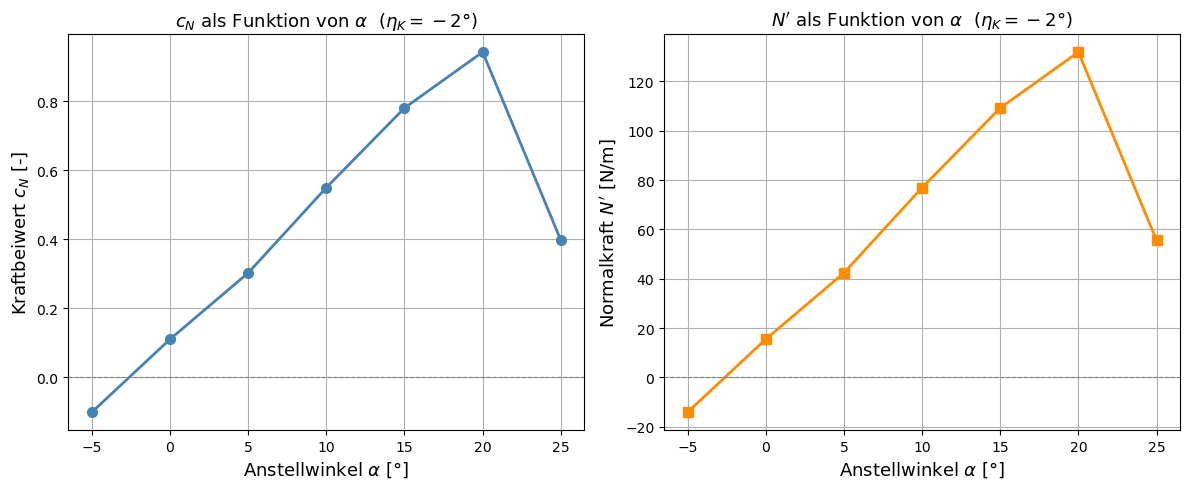

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].plot(alpha_var, cN_alpha, 'o-', color='steelblue', lw=2, ms=7)
axes[0].set_xlabel(r'Anstellwinkel $\alpha$ [°]', fontsize=13)
axes[0].set_ylabel(r'Kraftbeiwert $c_N$ [-]', fontsize=13)
axes[0].set_title(r'$c_N$ als Funktion von $\alpha$  ($\eta_K = -2°$)', fontsize=13)
axes[0].axhline(0, color='gray', lw=0.8, ls='--')
axes[0].grid(True)
 
axes[1].plot(alpha_var, N_prim_alpha, 's-', color='darkorange', lw=2, ms=7)
axes[1].set_xlabel(r'Anstellwinkel $\alpha$ [°]', fontsize=13)
axes[1].set_ylabel(r"Normalkraft $N'$ [N/m]", fontsize=13)
axes[1].set_title(r"$N'$ als Funktion von $\alpha$  ($\eta_K = -2°$)", fontsize=13)
axes[1].axhline(0, color='gray', lw=0.8, ls='--')
axes[1].grid(True)
 
plt.tight_layout()
plt.show()

### Analyse von $c_N$ und $N'$ für die Anstellwinkel-Variation

Die Diagramme zeigen den erwarteten Anstieg des Kraftbeiwerts $c_N$ mit zunehmendem Anstellwinkel $\alpha$. Bei kleinen Anstellwinkeln ($\alpha = -5°$ bis $\alpha \approx 5°$) ist der Anstieg annähernd linear, was dem theoretisch vorhergesagten Verhalten einer dünnen Tragfläche entspricht. Mit zunehmendem Anstellwinkel vergrößert sich die Druckdifferenz zwischen Unter- und Oberseite, da die Strömung auf der Oberseite stärker beschleunigt wird und dort niedrigere Drücke entstehen.

Bei hohen Anstellwinkeln ($\alpha \geq 20°$) ist eine Abflachung des $c_N$-Anstiegs zu beobachten, was auf eine beginnende Strömungsablösung an der Profiloberseite hindeutet. Dieser Effekt ist charakteristisch für den Übergang in den Strömungsabriss (Stall).

Die Normalkraft $N'$ folgt demselben Trend wie $c_N$, da $N' = c_N \cdot q_\infty \cdot c$ mit konstanten Werten für $q_\infty$ und $c$. Der Anstieg von $N'$ mit $\alpha$ verdeutlicht den aerodynamischen Nutzen einer Anstellwinkelerhöhung für die Auftriebserzeugung im normalen Betriebsbereich.

In [15]:
eta_var = [-2, 0, 5, 10, 15, 20, 25]
 
dateien_eta = [
    ['2024-05-06_11-48_alpha5_eta-2_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta-2_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta0_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta0_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta5_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta5_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta10_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta10_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta15_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta15_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta20_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta20_Messdaten_Unterseite.xlsx'],
    ['2024-05-06_11-48_alpha5_eta25_Messdaten_Oberseite.xlsx',
     '2024-05-06_11-48_alpha5_eta25_Messdaten_Unterseite.xlsx'],
]
 
cN_eta     = []
N_prim_eta = []
 
for i, eta in enumerate(eta_var):
    d_ober  = lese_druckdaten(os.path.join(folder_path, dateien_eta[i][0]))
    d_unter = lese_druckdaten(os.path.join(folder_path, dateien_eta[i][1]))
    cN      = berechne_cN(d_ober, d_unter, p_dyn_ref)
    N_prim  = cN * p_dyn_ref * c_profil
    cN_eta.append(cN)
    N_prim_eta.append(N_prim)
    print(f"eta_K = {eta:+3d}°  →  c_N = {cN:.4f},   N' = {N_prim:.2f} N/m")

eta_K =  -2°  →  c_N = 0.3024,   N' = 42.34 N/m
eta_K =  +0°  →  c_N = 0.3849,   N' = 53.89 N/m
eta_K =  +5°  →  c_N = 0.5019,   N' = 70.27 N/m
eta_K = +10°  →  c_N = 0.6303,   N' = 88.24 N/m
eta_K = +15°  →  c_N = 0.7496,   N' = 104.95 N/m
eta_K = +20°  →  c_N = 0.8449,   N' = 118.28 N/m
eta_K = +25°  →  c_N = 0.9389,   N' = 131.45 N/m


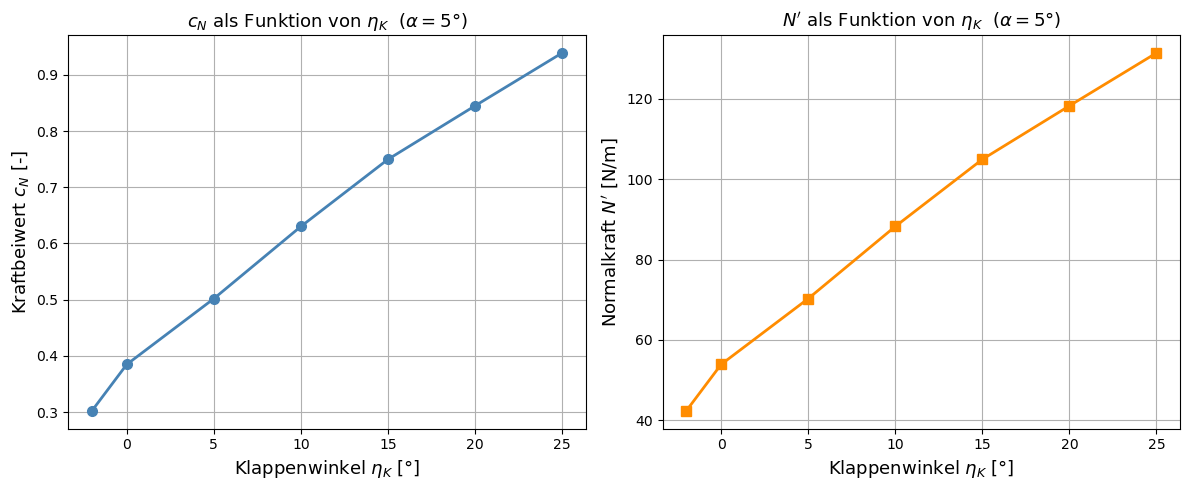

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].plot(eta_var, cN_eta, 'o-', color='steelblue', lw=2, ms=7)
axes[0].set_xlabel(r'Klappenwinkel $\eta_K$ [°]', fontsize=13)
axes[0].set_ylabel(r'Kraftbeiwert $c_N$ [-]', fontsize=13)
axes[0].set_title(r'$c_N$ als Funktion von $\eta_K$  ($\alpha = 5°$)', fontsize=13)
axes[0].grid(True)
 
axes[1].plot(eta_var, N_prim_eta, 's-', color='darkorange', lw=2, ms=7)
axes[1].set_xlabel(r'Klappenwinkel $\eta_K$ [°]', fontsize=13)
axes[1].set_ylabel(r"Normalkraft $N'$ [N/m]", fontsize=13)
axes[1].set_title(r"$N'$ als Funktion von $\eta_K$  ($\alpha = 5°$)", fontsize=13)
axes[1].grid(True)
 
plt.tight_layout()
plt.show()

### Analyse von $c_N$ und $N'$ für die Klappenwinkel-Variation

Bei konstantem Anstellwinkel $\alpha = 5°$ zeigt der Kraftbeiwert $c_N$ einen deutlichen Anstieg mit zunehmendem Klappenwinkel $\eta_K$. Das Ausfahren der Klappe bewirkt eine Vergrößerung der effektiven Profilwölbung und der Profiltiefe, wodurch die Zirkulation um das Profil zunimmt. Dies führt zu einer stärkeren Druckdifferenz zwischen Unter- und Oberseite und damit zu einem höheren $c_N$.

Verglichen mit der Anstellwinkel-Variation zeigt die Klappenwinkel-Variation einen ähnlichen Effekt auf den Auftrieb, jedoch bei gleichbleibender Anströmgeometrie. Dies ist aerodynamisch vorteilhaft, da beim Start und bei der Landung eines Flugzeugs ein hoher Auftrieb bei möglichst geringem Anstellwinkel erwünscht ist.

Die Normalkraft $N'$ steigt entsprechend mit $\eta_K$ an und bestätigt die Wirksamkeit der Fowlerklappe als Hochauftriebshilfe.